In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('student-por.csv', delimiter = ';')


In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
print("Dataset Shape (Rows, Columns):", df.shape)
print(df.dtypes)

Dataset Shape (Rows, Columns): (649, 33)
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [6]:
#check missing value
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
# Removing duplicates
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicates found.")
    
df.info()


Number of duplicate rows: 0
No duplicates found.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  

In [8]:
# Average Grade
avg_grade = df['G3'].mean()
print(f"The average final grade (G3) is: {avg_grade:.2f}")

The average final grade (G3) is: 11.91


In [9]:
# 3.2 How many students scored above 15?
high_scorers = df[df['G3'] > 15]
print(f"Number of students who scored above 15: {len(high_scorers)}")

Number of students who scored above 15: 82


In [10]:
correlation = df['studytime'].corr(df['G3'])
print(f"\nCorrelation between Study Time and Final Grade: {correlation:.3f}")


Correlation between Study Time and Final Grade: 0.250


In [11]:
# Interpretation of the correlation:
if abs(correlation) > 0.5:
    print("Interpretation: There is a strong correlation.")
elif abs(correlation) > 0.3:
    print("Interpretation: There is a moderate correlation.")
else:
    print("Interpretation: There is a weak or no correlation.")

Interpretation: There is a weak or no correlation.


In [12]:
# 3.4 Which gender performs better on average?
avg_grade_by_gender = df.groupby('sex')['G3'].mean()
print(f"\nAverage final grade by gender:\n{avg_grade_by_gender}")


Average final grade by gender:
sex
F    12.253264
M    11.406015
Name: G3, dtype: float64


In [13]:

# Determine which is higher
if avg_grade_by_gender['M'] > avg_grade_by_gender['F']:
    print("Conclusion: Male students have a higher average score.")
else:
    print("Conclusion: Female students have a higher average score.")

Conclusion: Female students have a higher average score.


Text(0, 0.5, 'Number of Students')

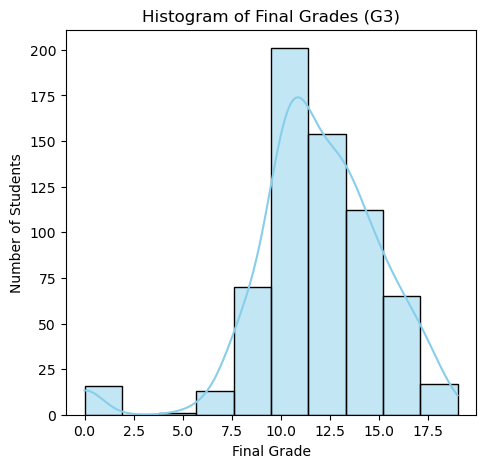

In [14]:
# Set up the plotting area size
plt.figure(figsize=(18, 5))

#  Plot 1: Histogram of Grades (G3) 
plt.subplot(1, 3, 1)
sns.histplot(df['G3'], bins=10, kde=True, color='skyblue')
plt.title('Histogram of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')

Text(0, 0.5, 'Final Grade')

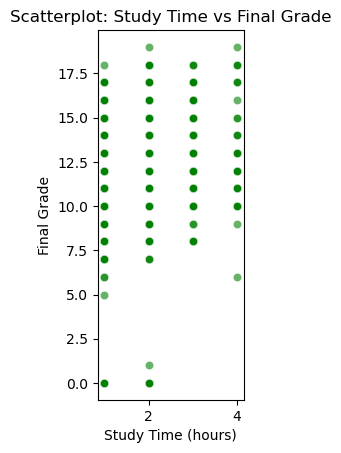

In [15]:
# Plot 2 Scatterplot: Study Time vs Grades
plt.subplot(1, 3, 2)
sns.scatterplot(x='studytime', y='G3', data=df, color='green', alpha=0.6)
plt.title('Scatterplot: Study Time vs Final Grade')
plt.xlabel('Study Time (hours)')
plt.ylabel('Final Grade')

C:\Users\Saurabh\AppData\Local\Temp\ipykernel_19872\744979835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='G3', data=gender_avg, palette='pastel')


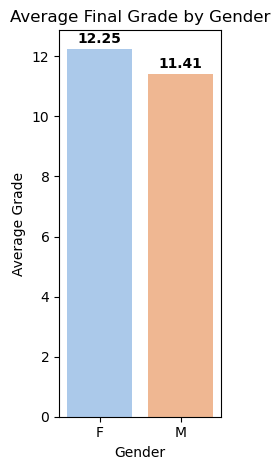

In [16]:
# Plot 3: Bar Chart: Male vs Female Average Score
plt.subplot(1, 3, 3)
gender_avg = df.groupby('sex')['G3'].mean().reset_index()
sns.barplot(x='sex', y='G3', data=gender_avg, palette='pastel')
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Grade')
# Add the exact value on top of the bars
for i, v in enumerate(gender_avg['G3']):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center', fontweight='bold')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()